In [3]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Setup Kaggle credentials
# Ensure kaggle.json is uploaded to /content directory
os.environ['KAGGLE_CONFIG_DIR'] = '/content'

# 2. Download and extract the dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d dataset


# 3. Define directory paths for training and testing
train_dir = 'dataset/chest_xray/train'
test_dir = 'dataset/chest_xray/test'
val_dir = 'dataset/chest_xray/val'

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:20<00:00, 118MB/s]



In [4]:
# 4. Data Preprocessing (Requirement 2)
# Apply Normalization by rescaling pixels to [0, 1]

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

 # Load data and apply Resizing to 224x224
 print("Loading Training Data...")
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)
print("\nLoading Testing Data...")
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# 1. Build CNN Model Architecture (Requirement 3)
# Including multiple hidden layers [cite: 3]
model = Sequential()

# First Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(BatchNormalization()) # Enhancement Technique [cite: 4]
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second Convolutional Block
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

#Third Convolutional Block
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Flatten())

# Dense Hidden Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5)) # تقنية تحسين (2): لمنع الحفظ (Overfitting)

# Output Layer

model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
# 1. Compile the model using the Adam optimizer (Experiment 1)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 2. Start Training
print("Starting Training - Experiment 1 (Adam Optimizer)...")

# We save the training results in 'history_adam' to plot the curves later
history_adam = model.fit(
    train_data,
    validation_data=test_data, # Using testing data to evaluate the model at each epoch
    epochs=5 # Number of training epochs (set to 5 for a reasonable training time)
)

Starting Training - Experiment 1 (Adam Optimizer)...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 347ms/step - accuracy: 0.8995 - loss: 0.8967 - val_accuracy: 0.6250 - val_loss: 35.9842
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 326ms/step - accuracy: 0.9208 - loss: 0.1946 - val_accuracy: 0.6250 - val_loss: 43.6784
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 324ms/step - accuracy: 0.9582 - loss: 0.1317 - val_accuracy: 0.6250 - val_loss: 29.5458
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 323ms/step - accuracy: 0.9622 - loss: 0.1047 - val_accuracy: 0.6266 - val_loss: 12.8716
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 324ms/step - accuracy: 0.9670 - loss: 0.1020 - val_accuracy: 0.8574 - val_loss: 0.4195


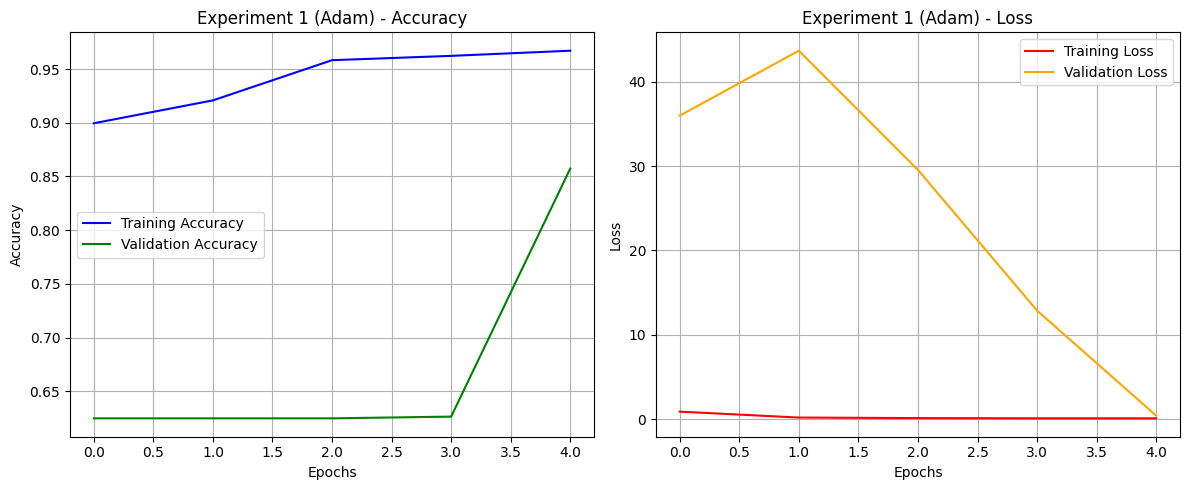

In [7]:
import matplotlib.pyplot as plt

# Training vs Validation Curves
plt.figure(figsize=(12, 5))

# 1. (Accuaracy Curve)
plt.subplot(1, 2, 1)
plt.plot(history_adam.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history_adam.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.title('Experiment 1 (Adam) - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 2.(Loss Curve)
plt.subplot(1, 2, 2)
plt.plot(history_adam.history['loss'], label='Training Loss', color='red')
plt.plot(history_adam.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Experiment 1 (Adam) - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Build a new model for the second experiment
model_sgd = Sequential()

model_sgd.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model_sgd.add(BatchNormalization())
model_sgd.add(MaxPooling2D(pool_size=(2, 2)))

model_sgd.add(Conv2D(64, (3, 3), activation='relu'))
model_sgd.add(BatchNormalization())
model_sgd.add(MaxPooling2D(pool_size=(2, 2)))

model_sgd.add(Conv2D(128, (3, 3), activation='relu'))
model_sgd.add(BatchNormalization())
model_sgd.add(MaxPooling2D(pool_size=(2, 2)))

model_sgd.add(Flatten())
model_sgd.add(Dense(128, activation='relu'))
model_sgd.add(Dropout(0.5))
model_sgd.add(Dense(1, activation='sigmoid'))

print("New model built successfully!")

New model built successfully!


In [10]:
# Compile the model using SGD
model_sgd.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Optimizer set to SGD. The model is ready for training!")

Optimizer set to SGD. The model is ready for training!


In [11]:
print("Starting Training - Experiment 2 (SGD)...")

history_sgd = model_sgd.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Starting Training - Experiment 2 (SGD)...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 338ms/step - accuracy: 0.9158 - loss: 0.3764 - val_accuracy: 0.6298 - val_loss: 2.1848
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 56s 343ms/step - accuracy: 0.9701 - loss: 0.0862 - val_accuracy: 0.6250 - val_loss: 3.6136
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 336ms/step - accuracy: 0.9749 - loss: 0.0644 - val_accuracy: 0.6250 - val_loss: 5.7887
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 337ms/step - accuracy: 0.9760 - loss: 0.0608 - val_accuracy: 0.7324 - val_loss: 1.2462
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 338ms/step - accuracy: 0.9864 - loss: 0.0410 - val_accuracy: 0.6490 - val_loss: 2.8018


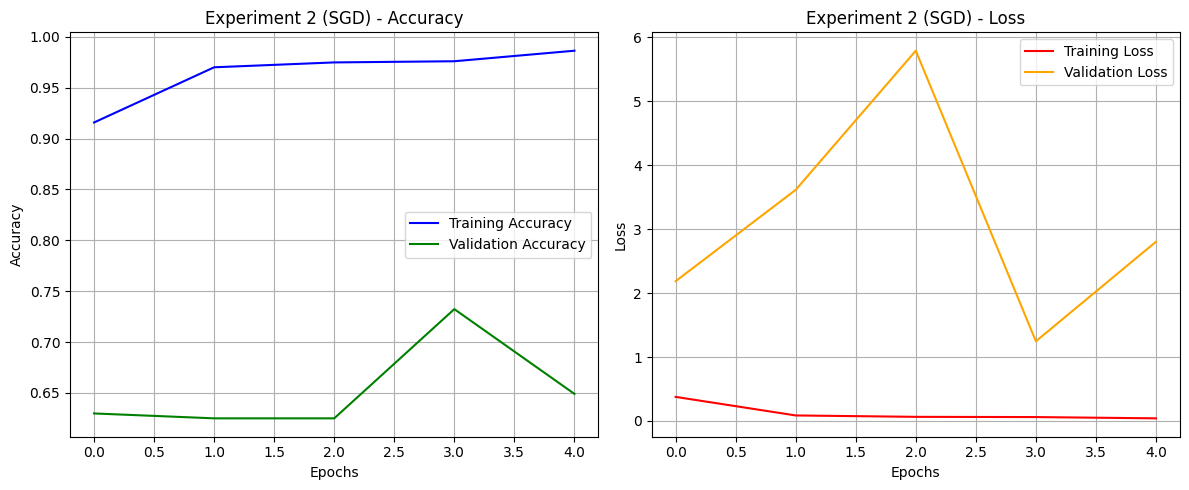

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history_sgd.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.title('Experiment 2 (SGD) - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['loss'], label='Training Loss', color='red')
plt.plot(history_sgd.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Experiment 2 (SGD) - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()